# 文件: chart_63_1.py

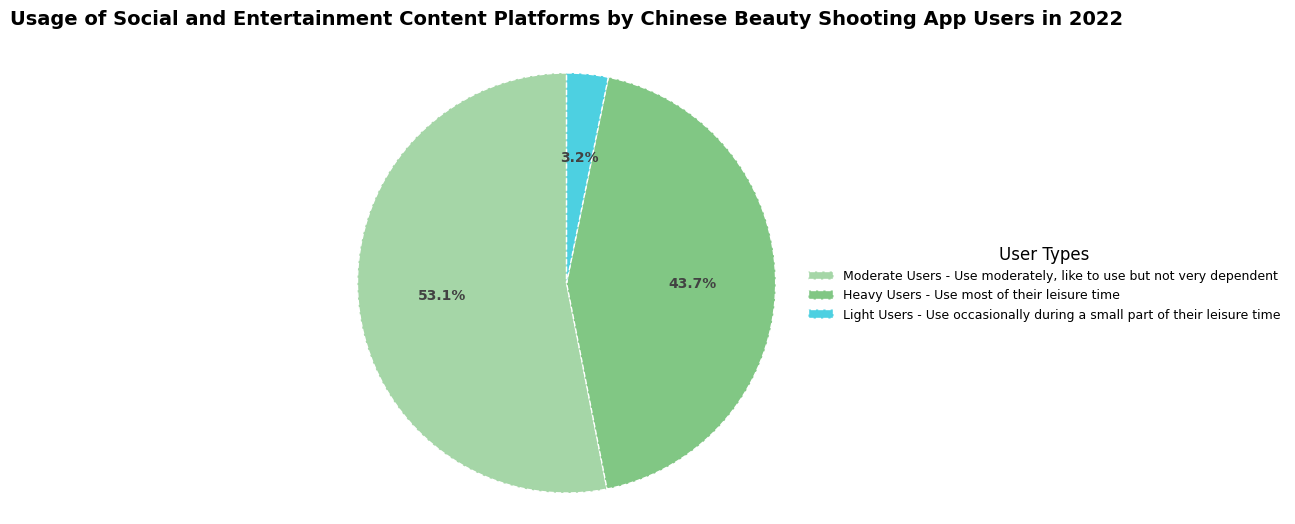

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------- Data Definition --------------------
categories = ["Moderate Users", "Heavy Users", "Light Users"]
sizes = [53.1, 43.7, 3.2]  # Proportion (percentage)

# Color configuration (similar to the original image)
colors = ["#a5d6a7", "#81c784", "#4dd0e1"]

# Legend descriptions (consistent with the original image)
legend_labels = [
    "Moderate Users - Use moderately, like to use but not very dependent",
    "Heavy Users - Use most of their leisure time",
    "Light Users - Use occasionally during a small part of their leisure time"
]

# -------------------- Create the canvas --------------------
fig, ax = plt.subplots(figsize=(8, 6))

# -------------------- Draw the pie chart --------------------
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,  # Do not set labels first, show them through the legend
    colors=colors,
    autopct='%1.1f%%',  # Show percentages
    startangle=90,      # Start drawing from 90 degrees (place moderate users on the right)
    wedgeprops={
        'edgecolor': 'white', 
        'linewidth': 1,
        # Dashed arc for heavy users: implemented by setting the 'linestyle' in wedgeprops
        'linestyle': 'dashed' if categories[1] == "Heavy Users" else 'solid'
    },  
    textprops={'fontsize': 10, 'color': '#424242', 'fontweight': 'bold'}  # Percentage text settings
)

# -------------------- Draw the dashed arc for heavy users (supplement the style not covered by the pie chart) --------------------
# Get the wedge of heavy users
heavy_user_wedge = wedges[1]
# Draw the dashed arc (from the start angle to the end angle)
theta1, theta2 = heavy_user_wedge.theta1, heavy_user_wedge.theta2
center, r = heavy_user_wedge.center, heavy_user_wedge.r

# -------------------- Beautify the chart --------------------
# Set the legend (adjust the position and style, consistent with the original image)
ax.legend(
    wedges, legend_labels,
    title="User Types",
    loc="center left",
    bbox_to_anchor=(1, 0.5),  # Place the legend in the middle on the right
    fontsize=9,
    title_fontsize=12,
    frameon=True,
    facecolor="white",
    edgecolor="white"
)

# Make the pie chart a perfect circle
ax.axis('equal')  

# Add a title
ax.set_title(
    "Usage of Social and Entertainment Content Platforms by Chinese Beauty Shooting App Users in 2022",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Adjust the layout (prevent the legend and title from overlapping)
plt.subplots_adjust(right=0.7)

plt.show()

# 文件: chart_63_2.py

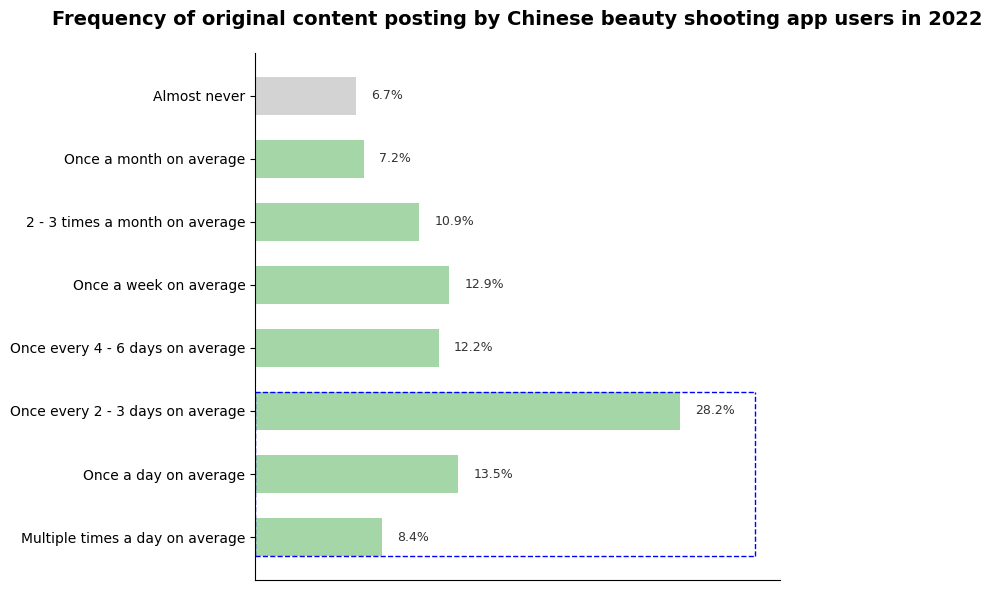

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data (Names, Percentages)
labels = [
    "Multiple times a day on average", "Once a day on average", "Once every 2 - 3 days on average",
    "Once every 4 - 6 days on average", "Once a week on average", "2 - 3 times a month on average",
    "Once a month on average", "Almost never"
]
percentages = [8.4, 13.5, 28.2, 12.2, 12.9, 10.9, 7.2, 6.7]

# Color configuration (Close to the original green color scheme, use gray for "Almost never")
colors = ["#a5d6a7"] * 7 + ["#d3d3d3"]

# Create a canvas
fig, ax = plt.subplots(figsize=(8, 6))

# Draw a horizontal bar chart
y = np.arange(len(labels))
bars = ax.barh(y, percentages, color=colors, height=0.6)

# Add data labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
            f"{width}%", va="center", fontsize=9, color="#333")

# Draw a blue dashed box (Select the top three items)
ax.plot([0, max(percentages) + 5], [y[0] - 0.3, y[0] - 0.3], color="blue", linestyle="--", linewidth=1)
ax.plot([0, max(percentages) + 5], [y[2] + 0.3, y[2] + 0.3], color="blue", linestyle="--", linewidth=1)
ax.plot([max(percentages) + 5, max(percentages) + 5], [y[0] - 0.3, y[2] + 0.3], color="blue", linestyle="--", linewidth=1)
ax.plot([0, 0], [y[0] - 0.3, y[2] + 0.3], color="blue", linestyle="--", linewidth=1)

# Set y - axis labels
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

# Hide x - axis ticks
ax.set_xticks([])

# Hide the top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a title
ax.set_title("Frequency of original content posting by Chinese beauty shooting app users in 2022", fontsize=14, fontweight="bold", pad=20)

# Adjust the layout
plt.tight_layout()
plt.show()

# 文件: chart_63_3.py

/var/folders/54/bbrbnf8953d7z0fzwhskm0b00000gn/T/ipykernel_60165/2351558815.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


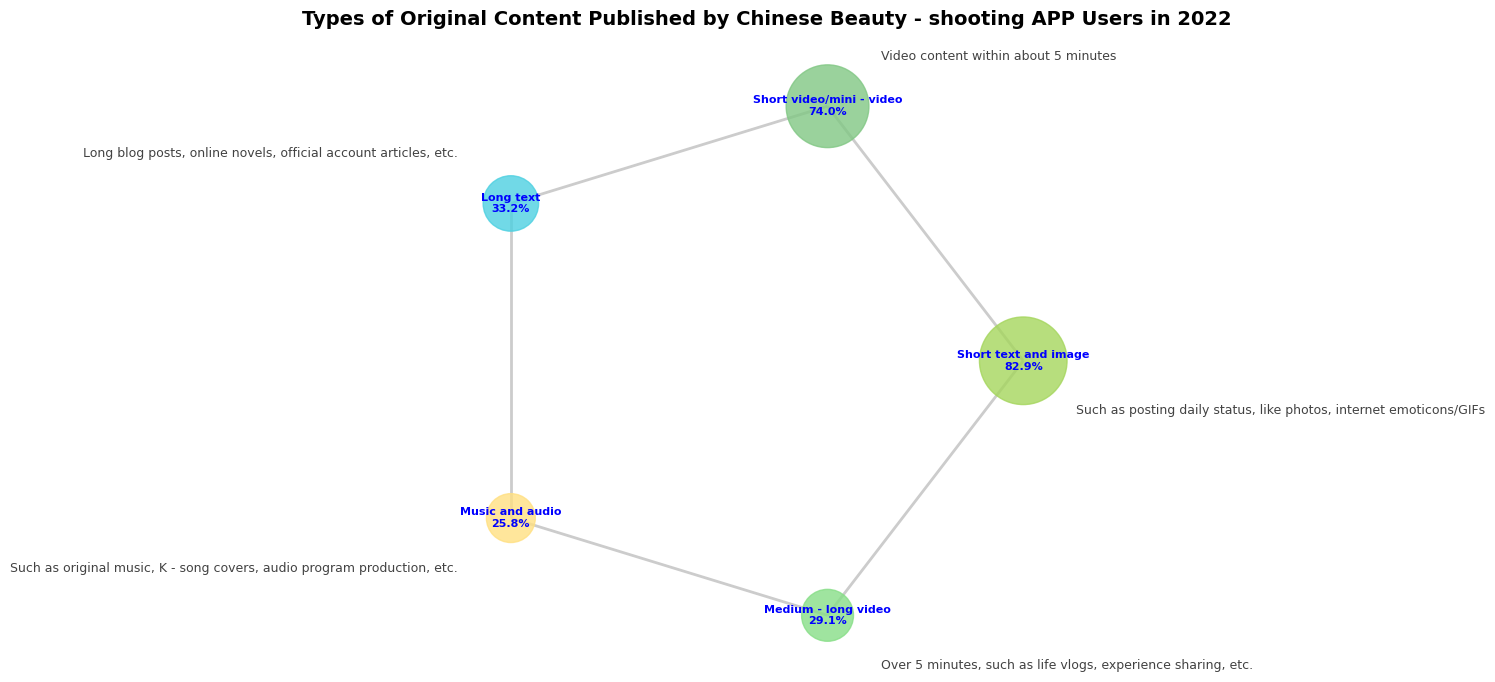

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# -------------------- Data Definition --------------------
# Node information: name, percentage, color
nodes = [
    {"name": "Short text and image", "percent": 82.9, "color": "#a5d65d", "desc": "Such as posting daily status, like photos, internet emoticons/GIFs"},
    {"name": "Short video/mini - video", "percent": 74.0, "color": "#81c784", "desc": "Video content within about 5 minutes"},
    {"name": "Long text", "percent": 33.2, "color": "#4dd0e1", "desc": "Long blog posts, online novels, official account articles, etc."},
    {"name": "Music and audio", "percent": 25.8, "color": "#ffe082", "desc": "Such as original music, K - song covers, audio program production, etc."},
    {"name": "Medium - long video", "percent": 29.1, "color": "#87de87", "desc": "Over 5 minutes, such as life vlogs, experience sharing, etc."}
]

# Connection relationships (simulating a circular connection)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 0)
]

# -------------------- Create Graph Structure --------------------
G = nx.Graph()
# Add nodes
for i, node in enumerate(nodes):
    G.add_node(i, 
               name=node["name"], 
               percent=node["percent"], 
               color=node["color"],
               desc=node["desc"])
# Add edges
G.add_edges_from(edges)

# -------------------- Layout Settings (Circular Layout) --------------------
pos = nx.circular_layout(G, scale=0.8)  # Circular layout, increase scale to disperse nodes

# -------------------- Create Canvas --------------------
fig, ax = plt.subplots(figsize=(8, 8))

# -------------------- Draw Nodes (with color and size) --------------------
node_sizes = [n["percent"] * 48 for n in nodes]  # Node size is positively correlated with the percentage
node_colors = [n["color"] for n in nodes]

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.8,
    ax=ax
)

# -------------------- Draw Edges (Gray Connecting Lines) --------------------
nx.draw_networkx_edges(
    G, pos,
    width=2,
    edge_color="#cccccc",
    ax=ax
)

# -------------------- Add Node Annotations (Name, Percentage, Description) --------------------
for i, node in enumerate(nodes):
    # Annotate the name and percentage (inside the node)
    ax.text(
        pos[i][0], pos[i][1], 
        f"{node['name']}\n{node['percent']}%",
        ha="center", va="center",
        fontsize=8,
        color="blue",
        fontweight="bold"
    )
    # Annotate the description information (outside the node, adjust the offset)
    desc_x = pos[i][0] + (1.5 if pos[i][0] > 0 else -1.5) * 0.1  # Horizontal offset
    desc_y = pos[i][1] + (1.5 if pos[i][1] > 0 else -1.5) * 0.1  # Vertical offset
    ax.text(
        desc_x, desc_y, 
        node["desc"],
        ha="left" if pos[i][0] > 0 else "right",
        va="center",
        fontsize=9,
        color="#424242"
    )

# -------------------- Beautify the Chart --------------------
# Hide the axes
ax.axis("off")

# Add a title
ax.set_title(
    "Types of Original Content Published by Chinese Beauty - shooting APP Users in 2022",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Adjust the layout
plt.tight_layout()

plt.show()

# 文件: chart_63_4.py

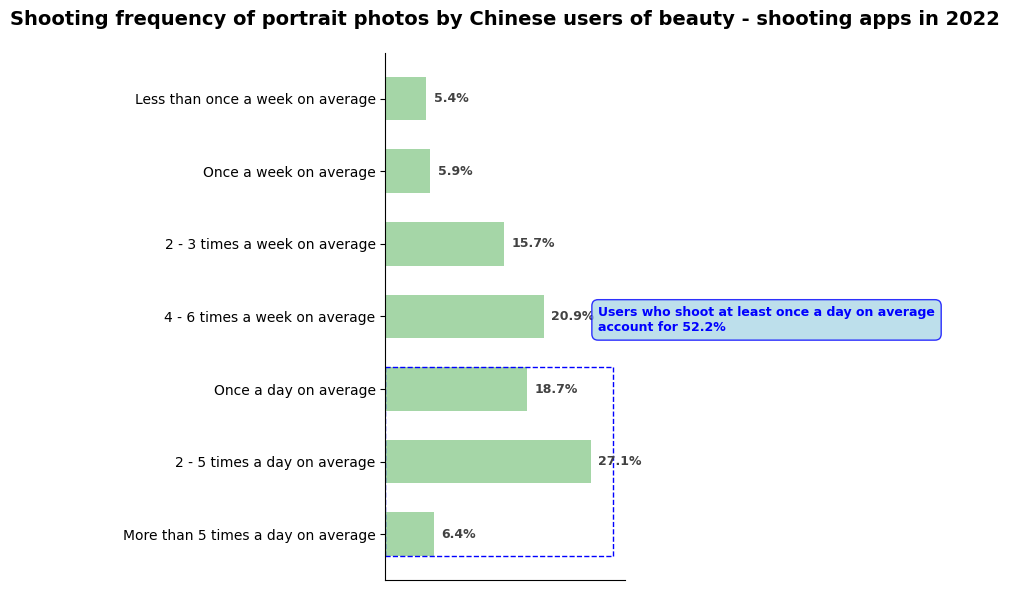

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------- Data Definition --------------------
# Shooting frequency categories
labels = [
    "More than 5 times a day on average", "2 - 5 times a day on average", "Once a day on average",
    "4 - 6 times a week on average", "2 - 3 times a week on average", "Once a week on average",
    "Less than once a week on average"
]
# Percentage data
percentages = [6.4, 27.1, 18.7, 20.9, 15.7, 5.9, 5.4]

# Group markers (The first three items are "Shoot at least once a day on average")
group_indices = [0, 1, 2]  # Indices of the first three items

# Color configuration (Close to the green color scheme in the original image)
bar_colors = ["#a5d6a7"] * len(labels)

# Annotation text (Blue box in the upper - right corner)
annotation_text = "Users who shoot at least once a day on average\naccount for 52.2%"
annotation_box = {
    "boxstyle": "round,pad=0.5",
    "facecolor": "lightblue",
    "edgecolor": "blue",
    "alpha": 0.8
}

# -------------------- Create a canvas --------------------
fig, ax = plt.subplots(figsize=(8, 6))

# -------------------- Draw a horizontal bar chart --------------------
y = np.arange(len(labels))

bars = ax.barh(
    y, 
    percentages, 
    color=bar_colors, 
    height=0.6
)

# -------------------- Add data annotations --------------------
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1, 
        bar.get_y() + bar.get_height() / 2,
        f"{width}%",
        va="center", 
        fontsize=9, 
        color="#424242",
        fontweight="bold"
    )

# -------------------- Draw a dashed box for the group --------------------
# Find the minimum and maximum y - coordinates of the group
min_y = min([y[i] for i in group_indices]) - 0.3
max_y = max([y[i] for i in group_indices]) + 0.3
max_width = max([percentages[i] for i in group_indices]) + 3  # Width of the dashed box

# Draw the dashed box
ax.plot([0, max_width], [min_y, min_y], color="blue", linestyle="--", linewidth=1)
ax.plot([0, max_width], [max_y, max_y], color="blue", linestyle="--", linewidth=1)
ax.plot([max_width, max_width], [min_y, max_y], color="blue", linestyle="--", linewidth=1)
ax.plot([0, 0], [min_y, max_y], color="blue", linestyle="--", linewidth=1)

# -------------------- Add an annotation in the upper - right corner --------------------
ax.text(
    max_width - 2,  # Horizontal position
    max_y + 0.5,    # Vertical position (Above the dashed box)
    annotation_text,
    fontsize=9,
    color="blue",
    fontweight="bold",
    bbox=annotation_box
)

# -------------------- Beautify the chart --------------------
# Set y - axis labels
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

# Hide x - axis ticks
ax.set_xticks([])

# Hide the top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a title
ax.set_title(
    "Shooting frequency of portrait photos by Chinese users of beauty - shooting apps in 2022",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Adjust the layout
plt.tight_layout()

plt.show()